In [1]:
import numpy as np
from scipy.optimize import minimize
import matplotlib.pyplot as plt
import pickle
import wntr
import pandas as pd

In [2]:
# Create a water network model
inp_file = 'CTOWN.inp'
wn = wntr.network.WaterNetworkModel(inp_file)

C:\Users\Admin\anaconda3\lib\site-packages\wntr\epanet\io.py:2082: UserWarning: Not all curves were used in "CTOWN.inp"; added with type None, units conversion left to user
  warnings.warn('Not all curves were used in "{}"; added with type None, units conversion left to user'.format(self.wn.name))


['J511', 'J411', 'J414', 'J415', 'J416', 'J417', 'J418', 'J419', 'J310', 'J311', 'J312', 'J313', 'J314', 'J315', 'J316', 'J318', 'J319', 'J210', 'J211', 'J212', 'J214', 'J217', 'J218', 'J219', 'J110', 'J420', 'J421', 'J422', 'J1153', 'J1154', 'J1155', 'J425', 'J426', 'J1157', 'J427', 'J1158', 'J428', 'J429', 'J320', 'J321', 'J322', 'J324', 'J1056', 'J327', 'J1058', 'J328', 'J329', 'J220', 'J221', 'J225', 'J226', 'J50', 'J51', 'J53', 'J54', 'J128', 'J55', 'J129', 'J56', 'J57', 'J58', 'J59', 'J1160', 'J1161', 'J431', 'J432', 'J433', 'J434', 'J435', 'J436', 'J438', 'J1169', 'J439', 'J330', 'J331', 'J332', 'J333', 'J334', 'J335', 'J336', 'J337', 'J231', 'J232', 'J233', 'J234', 'J236', 'J237', 'J130', 'J131', 'J132', 'J133', 'J60', 'J134', 'J135', 'J62', 'J64', 'J65', 'J66', 'J67', 'J68', 'J69', 'J1170', 'J441', 'J444', 'J341', 'J344', 'J345', 'J347', 'J348', 'J349', 'J241', 'J242', 'J243', 'J244', 'J245', 'J246', 'J247', 'J248', 'J249', 'J142', 'J143', 'J70', 'J144', 'J71', 'J72', 'J73', '

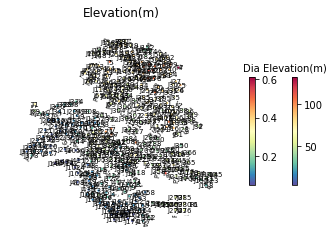

In [3]:
#ax = wntr.graphics.plot_network(wn, node_attribute='elevation',node_colorbar_label='Elevation(m)')
A=wn.node_name_list
print(A)
B=wn.link_name_list
print(B)
ax = wntr.graphics.network.plot_network(wn, node_attribute='elevation', link_attribute='diameter', title='Elevation(m)', node_size=5, node_range=[None, None], node_alpha=1, node_cmap=None, node_labels=True, link_width=1, link_range=[None, None], link_alpha=1, link_cmap=None, link_labels=True, add_colorbar=True, node_colorbar_label='Elevation(m)', link_colorbar_label='Dia', directed=False, ax=None, filename=None)

In [4]:
A2 = ['P1', 'P10', 'P100', 'P1000', 'P101', 'P1016', 'P102', 'P1022', 'P1023', 'P1024', 'P1025', 'P1026', 'P1027', 'P1028', 'P1029', 'P103', 'P1030', 'P1031', 'P1032', 'P1033', 'P1034', 'P1035', 'P1036', 'P1039', 'P104', 'P1040', 'P1041', 'P1042', 'P1044', 'P1045', 'P106', 'P107', 'P108', 'P109', 'P11', 'P110', 'P111', 'P112', 'P113', 'P115', 'P116', 'P117', 'P118', 'P119', 'P12', 'P120', 'P121', 'P122', 'P123', 'P124', 'P125', 'P126', 'P127', 'P128', 'P129', 'P13', 'P130', 'P131', 'P132', 'P134', 'P136', 'P138', 'P139', 'P14', 'P140', 'P141', 'P142', 'P144', 'P147', 'P148', 'P15', 'P150', 'P154', 'P155', 'P156', 'P157', 'P158', 'P159', 'P16', 'P160', 'P161', 'P162', 'P163', 'P165', 'P166', 'P17', 'P174', 'P177', 'P18', 'P184', 'P19', 'P195', 'P2', 'P20', 'P201', 'P21', 'P211', 'P215', 'P218', 'P219', 'P22', 'P220', 'P223', 'P225', 'P228', 'P23', 'P230', 'P231', 'P233', 'P234', 'P235', 'P237', 'P238', 'P24', 'P241', 'P242', 'P243', 'P245', 'P246', 'P248', 'P249', 'P25', 'P251', 'P252', 'P255', 'P256', 'P258', 'P259', 'P26', 'P264', 'P266', 'P267', 'P268', 'P27', 'P270', 'P272', 'P275', 'P28', 'P280', 'P282', 'P284', 'P285', 'P286', 'P287', 'P288', 'P29', 'P290', 'P291', 'P292', 'P293', 'P294', 'P295', 'P296', 'P297', 'P298', 'P299', 'P3', 'P30', 'P301', 'P302', 'P303', 'P304', 'P305', 'P307', 'P308', 'P309', 'P31', 'P310', 'P316', 'P319', 'P32', 'P320', 'P322', 'P323', 'P329', 'P33', 'P330', 'P331', 'P336', 'P337', 'P338', 'P339', 'P34', 'P340', 'P341', 'P343', 'P344', 'P346', 'P347', 'P348', 'P349', 'P35', 'P350', 'P37', 'P372', 'P374', 'P375', 'P376', 'P378', 'P379', 'P38', 'P380', 'P381', 'P383', 'P384', 'P385', 'P386', 'P39', 'P397', 'P398', 'P399', 'P40', 'P402', 'P403', 'P409', 'P410', 'P42', 'P424', 'P43', 'P44', 'P443', 'P445', 'P446', 'P450', 'P46', 'P465', 'P467', 'P468', 'P48', 'P482', 'P484', 'P49', 'P492', 'P5', 'P500', 'P501', 'P502', 'P51', 'P510', 'P52', 'P524', 'P527', 'P529', 'P53', 'P54', 'P55', 'P57', 'P58', 'P596', 'P597', 'P6', 'P609', 'P610', 'P63', 'P633', 'P64', 'P65', 'P67', 'P670', 'P671', 'P68', 'P69', 'P697', 'P7', 'P70', 'P71', 'P72', 'P724', 'P725', 'P752', 'P753', 'P754', 'P755', 'P756', 'P757', 'P758', 'P759', 'P760', 'P761', 'P763', 'P766', 'P767', 'P768', 'P769', 'P771', 'P772', 'P775', 'P776', 'P777', 'P779', 'P780', 'P781', 'P783', 'P784', 'P785', 'P786', 'P787', 'P788', 'P789', 'P791', 'P794', 'P795', 'P796', 'P797', 'P798', 'P8', 'P800', 'P801', 'P804', 'P805', 'P806', 'P807', 'P808', 'P809', 'P810', 'P811', 'P813', 'P815', 'P817', 'P819', 'P821', 'P822', 'P823', 'P826', 'P827', 'P83', 'P830', 'P831', 'P84', 'P840', 'P841', 'P842', 'P844', 'P846', 'P847', 'P85', 'P850', 'P851', 'P852', 'P853', 'P855', 'P858', 'P859', 'P86', 'P861', 'P866', 'P87', 'P871', 'P880', 'P889', 'P89', 'P892', 'P9', 'P90', 'P91', 'P914', 'P915', 'P92', 'P924', 'P927', 'P929', 'P930', 'P931', 'P932', 'P933', 'P934', 'P935', 'P937', 'P938', 'P939', 'P94', 'P940', 'P941', 'P942', 'P943', 'P944', 'P946', 'P947', 'P948', 'P949', 'P95', 'P951', 'P953', 'P954', 'P955', 'P956', 'P957', 'P958', 'P959', 'P96', 'P961', 'P962', 'P963', 'P964', 'P965', 'P966', 'P967', 'P968', 'P969', 'P97', 'P970', 'P971', 'P972', 'P973', 'P974', 'P975', 'P976', 'P977', 'P978', 'P98', 'P981', 'P982', 'P983', 'P984', 'P986', 'P987', 'P988', 'P989', 'P99', 'P990', 'P991', 'P992', 'P993', 'P994', 'P995', 'P996', 'P997', 'P998', 'P999']

In [5]:
coeff = [[],[]]
for i in range(len(A2)):
    junction = wn.get_link(A2[i])
    #junction.demand_timeseries_list[0].pattern_name=A[i+9]
    pat_i = junction.roughness
    coeff[0].append(A2[i])
    coeff[1].append(pat_i)
    print(f'{A2[i]} have coeff {pat_i}')

P1 have coeff 72.4549266
P10 have coeff 108.0095074
P100 have coeff 76.51422883
P1000 have coeff 76.94614787
P101 have coeff 84.20845169
P1016 have coeff 85.23817366
P102 have coeff 92.94722922
P1022 have coeff 99.58078005
P1023 have coeff 95.68850653
P1024 have coeff 89.62069894
P1025 have coeff 97.77659267
P1026 have coeff 88.45039526
P1027 have coeff 92.0106009
P1028 have coeff 86.99339612
P1029 have coeff 91.33959845
P103 have coeff 79.37099717
P1030 have coeff 104.6083303
P1031 have coeff 84.37414232
P1032 have coeff 98.43095137
P1033 have coeff 84.68939593
P1034 have coeff 97.41854735
P1035 have coeff 97.7581413
P1036 have coeff 74.29791874
P1039 have coeff 92.14229573
P104 have coeff 99.88658284
P1040 have coeff 94.68876721
P1041 have coeff 112.5081558
P1042 have coeff 76.15024112
P1044 have coeff 100.2182444
P1045 have coeff 118.82139
P106 have coeff 63.55113264
P107 have coeff 80.50983232
P108 have coeff 78.72048108
P109 have coeff 76.89340854
P11 have coeff 96.83442437
P110 h

In [6]:
coeff

[['P1',
  'P10',
  'P100',
  'P1000',
  'P101',
  'P1016',
  'P102',
  'P1022',
  'P1023',
  'P1024',
  'P1025',
  'P1026',
  'P1027',
  'P1028',
  'P1029',
  'P103',
  'P1030',
  'P1031',
  'P1032',
  'P1033',
  'P1034',
  'P1035',
  'P1036',
  'P1039',
  'P104',
  'P1040',
  'P1041',
  'P1042',
  'P1044',
  'P1045',
  'P106',
  'P107',
  'P108',
  'P109',
  'P11',
  'P110',
  'P111',
  'P112',
  'P113',
  'P115',
  'P116',
  'P117',
  'P118',
  'P119',
  'P12',
  'P120',
  'P121',
  'P122',
  'P123',
  'P124',
  'P125',
  'P126',
  'P127',
  'P128',
  'P129',
  'P13',
  'P130',
  'P131',
  'P132',
  'P134',
  'P136',
  'P138',
  'P139',
  'P14',
  'P140',
  'P141',
  'P142',
  'P144',
  'P147',
  'P148',
  'P15',
  'P150',
  'P154',
  'P155',
  'P156',
  'P157',
  'P158',
  'P159',
  'P16',
  'P160',
  'P161',
  'P162',
  'P163',
  'P165',
  'P166',
  'P17',
  'P174',
  'P177',
  'P18',
  'P184',
  'P19',
  'P195',
  'P2',
  'P20',
  'P201',
  'P21',
  'P211',
  'P215',
  'P218',
  '

In [7]:
#C_mat = np.array(coeff[1]+np.random.randint(-2, 2,np.shape(coeff)[1]))

In [1]:
Q_p = pd.read_csv("Q_quality_gt1.csv")
D_p = pd.read_csv("patt_quality_gt1.csv")
P_m = pd.read_csv("P_quality_gt1.csv")
dos_p = pd.read_csv("dossing_gt1.csv")
pat_n  = pd.read_csv("Pat_name.csv")

NameError: name 'pd' is not defined

In [9]:
D_p

,Unnamed: 0,0,1,2,3,4,5,6,7,8,...,5366,5367,5368,5369,5370,5371,5372,5373,5374,5375
0,0,0.584836,0.454694,0.433095,0.338027,0.310576,0.322725,0.420209,0.454502,0.507552,...,0.594090,0.608435,0.593578,0.665773,0.635262,0.705950,0.779173,0.821903,0.941212,0.810422
1,1,0.564130,0.453078,0.452341,0.352076,0.306890,0.325615,0.384138,0.488006,0.551391,...,0.561997,0.577994,0.568410,0.622985,0.571199,0.774500,0.696642,0.788714,0.901753,0.869485
2,2,0.573436,0.448752,0.444788,0.363562,0.310624,0.329966,0.371491,0.467190,0.552732,...,0.565490,0.572809,0.588063,0.630818,0.556321,0.754910,0.712469,0.786997,0.902549,0.848312
3,3,0.573661,0.476746,0.444334,0.346391,0.313613,0.336360,0.387514,0.489071,0.543683,...,0.557045,0.581509,0.584161,0.627467,0.559748,0.767063,0.712153,0.773191,0.899085,0.856548
4,4,0.522941,0.459581,0.448544,0.299940,0.321026,0.315678,0.430518,0.420152,0.560071,...,0.645605,0.617688,0.655696,0.655619,0.642344,0.710192,0.771353,0.733948,0.914571,0.789722
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
329,329,0.624550,0.449848,0.425922,0.340974,0.313991,0.305652,0.424439,0.439984,0.502905,...,0.567673,0.605814,0.588476,0.648100,0.627491,0.694501,0.784005,0.802225,0.932128,0.782922
330,330,0.619272,0.452124,0.431054,0.334791,0.325762,0.318850,0.420226,0.440753,0.494284,...,0.587910,0.604921,0.600370,0.651076,0.625531,0.684377,0.793366,0.824657,0.925223,0.804903
331,331,0.512911,0.455989,0.434424,0.316924,0.332877,0.324478,0.407116,0.412746,0.579417,...,0.633697,0.602581,0.654317,0.652691,0.630110,0.705609,0.773198,0.731680,0.930475,0.776493
332,332,0.538453,0.455966,0.448756,0.304988,0.328337,0.316940,0.427100,0.426040,0.572210,...,0.647163,0.620820,0.670858,0.638856,0.622502,0.707162,0.777563,0.766624,0.936825,0.764652


In [10]:
Q_p

,Unnamed: 0,J511,J411,J414,J415,J416,J417,J418,J419,J310,...,J317,J323,R1,T3,T1,T7,T6,T5,T2,T4
0,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,...,0.000000,0.0,0.0040,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000
1,3600,0.000133,0.001037,0.000849,0.000816,0.000808,0.000835,0.0,0.000809,0.000007,...,0.000010,0.0,0.0040,0.000112,0.000000e+00,7.891982e-07,3.931182e-07,0.000002,0.000228,0.000000
2,7200,0.000552,0.001527,0.001342,0.003183,0.003152,0.001331,0.0,0.001289,0.000519,...,0.000795,0.0,0.0032,0.000582,0.000000e+00,9.323162e-05,4.287804e-07,0.000120,0.000453,0.000045
3,10800,0.000753,0.001643,0.001387,0.001339,0.001324,0.001370,0.0,0.001323,0.002951,...,0.000000,0.0,0.0032,0.000950,0.000000e+00,3.066569e-04,4.287804e-07,0.000473,0.000602,0.000115
4,14400,0.000673,0.001900,0.001585,0.004742,0.004693,0.001564,0.0,0.001523,0.001398,...,0.000000,0.0,0.0032,0.001673,6.279805e-07,3.066569e-04,4.287804e-07,0.001209,0.000789,0.000177
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5372,19339200,0.001238,0.003423,0.002991,0.002907,0.002886,0.002965,0.0,0.002891,0.002412,...,0.003185,0.0,0.0072,0.005284,1.361822e-03,1.418256e-03,2.391882e-03,0.002574,0.002469,0.000755
5373,19342800,0.001154,0.003402,0.002941,0.004775,0.004729,0.002903,0.0,0.002824,0.001106,...,0.001576,0.0,0.0072,0.005284,1.361822e-03,1.413845e-03,2.369918e-03,0.002553,0.002492,0.000755
5374,19346400,0.001081,0.003403,0.002961,0.003184,0.003154,0.002933,0.0,0.002745,0.001186,...,0.001592,0.0,0.0072,0.005044,1.361822e-03,1.356966e-03,2.369918e-03,0.002553,0.002494,0.000755
5375,19350000,0.000616,0.003419,0.002991,0.005572,0.005521,0.002966,0.0,0.002319,0.001037,...,0.001391,0.0,0.0072,0.005162,1.361822e-03,1.356966e-03,2.369918e-03,0.002553,0.002494,0.000755


In [11]:
initial_q  = Q_p.iloc[20,1:]
initial_q

J511    0.001033
J411    0.001234
J414    0.001069
J415    0.005572
J416    0.005522
          ...   
T7      0.000793
T6      0.000319
T5      0.001679
T2      0.000975
T4      0.000245
Name: 20, Length: 396, dtype: float64

In [12]:
D_p1 = D_p.iloc[:,21]
D_p1

0      0.833463
1      0.850090
2      0.870808
3      0.859452
4      0.848871
         ...   
329    0.820382
330    0.852471
331    0.845295
332    0.829174
333    0.850664
Name: 20, Length: 334, dtype: float64

In [13]:
zero_demand=['J415', 'J416', 'J418', 'J419', 'J420', 'J422', 'J425', 'J426', 'J427', 'J233', 'J441', 'J363', 'J364', 'J371', 'J384', 'J385', 'J394', 'J399', 'J401', 'J406', 'J407', 'J14', 'J15', 'J16', 'J17', 'J18', 'J19', 'J20', 'J21', 'J22', 'J23', 'J256', 'J269', 'J273', 'J274', 'J276', 'J280', 'J285', 'J287', 'J288', 'J289', 'J290', 'J291', 'J292', 'J299', 'J300', 'J301', 'J302', 'J304', 'J306', 'J307', 'J309', 'J317', 'J323']

In [14]:
Q_p1 = Q_p.iloc[21,1:]
Q_p1=Q_p1.drop(zero_demand)

In [15]:
Q_p1

J511    0.000669
J411    0.001299
J414    0.001118
J417    0.001106
J310    0.000178
          ...   
T7      0.000793
T6      0.000319
T5      0.001465
T2      0.000978
T4      0.000245
Name: 21, Length: 342, dtype: float64

In [16]:
P_m1 = P_m.iloc[20,1:]
P_m1

J511    30.206692
J411    62.451958
J414    34.103264
J415    83.628100
J416    97.880490
          ...    
T7       2.977295
T6       5.499999
T5       1.784633
T2       1.519196
T4       2.808587
Name: 20, Length: 396, dtype: float64

In [17]:
# Q_m =  Q_p.filter(sensor_no, axis=1)
# Q_m

In [18]:
len(D_p1)

334

In [19]:
wn.options.hydraulic.demand_model = 'PDA'

In [20]:
A = ['0','1','2','3','4','5','6','7','8',
 '9','10','11',
 '12',
 '13',
 '14','15',
 '16','17',
 '18','19',
 '20',
 '21',
 '22',
 '23',
 '24',
 '25',
 '26',
 '27',
 '28',
 '29',
 '30',
 '31',
 '32',
 '33',
 '34',
 '35',
 '36',
 '37',
 '38',
 '39',
 '40',
 '41',
 '42',
 '43',
 '44',
 '45',
 '46',
 '47',
 '48',
 '49',
 '50',
 '51',
 '52',
 '53',
 '54',
 '55',
 '56',
 '57',
 '58',
 '59',
 '60',
 '61',
 '62',
 '63',
 '64',
 '65',
 '66',
 '67',
 '68',
 '69',
 '70',
 '71',
 '72',
 '73',
 '74',
 '75',
 '76',
 '77',
 '78',
 '79',
 '80',
 '81',
 '82',
 '83',
 '84',
 '85',
 '86',
 '87',
 '88',
 '89',
 '90',
 '91',
 '92',
 '93',
 '94',
 '95',
 '96',
 '97',
 '98',
 '99',
 '100',
 '101',
 '102',
 '103',
 '104',
 '105',
 '106',
 '107',
 '108',
 '109',
 '110',
 '111',
 '112',
 '113',
 '114',
 '115',
 '116',
 '117',
 '118',
 '119',
 '120',
 '121',
 '122',
 '123',
 '124',
 '125',
 '126',
 '127',
 '128',
 '129',
 '130',
 '131',
 '132',
 '133',
 '134',
 '135',
 '136',
 '137',
 '138',
 '139',
 '140',
 '141',
 '142',
 '143',
 '144',
 '145',
 '146',
 '147',
 '148',
 '149',
 '150',
 '151',
 '152',
 '153',
 '154',
 '155',
 '156',
 '157',
 '158',
 '159',
 '160',
 '161',
 '162',
 '163',
 '164',
 '165',
 '166',
 '167',
 '168',
 '169',
 '170',
 '171',
 '172',
 '173',
 '174',
 '175',
 '176',
 '177',
 '178',
 '179',
 '180',
 '181',
 '182',
 '183',
 '184',
 '185',
 '186',
 '187',
 '188',
 '189',
 '190',
 '191',
 '192',
 '193',
 '194',
 '195',
 '196',
 '197',
 '198',
 '199',
 '200',
 '201',
 '202',
 '203',
 '204',
 '205',
 '206',
 '207',
 '208',
 '209',
 '210',
 '211',
 '212',
 '213',
 '214',
 '215',
 '216',
 '217',
 '218',
 '219',
 '220',
 '221',
 '222',
 '223',
 '224',
 '225',
 '226',
 '227',
 '228',
 '229',
 '230',
 '231',
 '232',
 '233',
 '234',
 '235',
 '236',
 '237',
 '238',
 '239',
 '240',
 '241',
 '242',
 '243',
 '244',
 '245',
 '246',
 '247',
 '248',
 '249',
 '250',
 '251',
 '252',
 '253',
 '254',
 '255',
 '256',
 '257',
 '258',
 '259',
 '260',
 '261',
 '262',
 '263',
 '264',
 '265',
 '266',
 '267',
 '268',
 '269',
 '270',
 '271',
 '272',
 '273',
 '274',
 '275',
 '276',
 '277',
 '278',
 '279',
 '280',
 '281',
 '282',
 '283',
 '284',
 '285',
 '286',
 '287',
 '288',
 '289',
 '290',
 '291',
 '292',
 '293',
 '294',
 '295',
 '296',
 '297',
 '298',
 '299',
 '300',
 '301',
 '302',
 '303',
 '304',
 '305',
 '306',
 '307',
 '308',
 '309',
 '310',
 '311',
 '312',
 '313',
 '314',
 '315',
 '316',
 '317',
 '318',
 '319',
 '320',
 '321',
 '322',
 '323',
 '324',
 '325',
 '326',
 '327',
 '328',
 '329',
 '330',
 '331',
 '332',
 '333']

In [21]:
pat_n

,Unnamed: 0,0,1
0,0,J511,DMA2_pat
1,1,J411,DMA1_pat
2,2,J414,DMA1_pat
3,5,J417,DMA1_pat
4,8,J310,DMA4_pat
...,...,...,...
329,361,J222,DMA2_pat
330,362,J224,DMA2_pat
331,363,J230,DMA4_pat
332,364,J235,DMA4_pat


In [22]:
'''#pat3 = wn.get_pattern('2')
#A = ['10', '11', '12', '13', '21', '22', '23', '31', '32','2', '3', '4', '5', '6', '7', '8', '9', '10']
#P = ['2', '3', '4', '5', '6', '7', '8', '9', '10']
for i in range(334):
    junction = wn.get_node(pat_n.iloc[i][1])
    junction.demand_timeseries_list[0].pattern_name=A[i]
    #print(junction.demand_timeseries_list[0].pattern_name)'''
        

"#pat3 = wn.get_pattern('2')\n#A = ['10', '11', '12', '13', '21', '22', '23', '31', '32','2', '3', '4', '5', '6', '7', '8', '9', '10']\n#P = ['2', '3', '4', '5', '6', '7', '8', '9', '10']\nfor i in range(334):\n    junction = wn.get_node(pat_n.iloc[i][1])\n    junction.demand_timeseries_list[0].pattern_name=A[i]\n    #print(junction.demand_timeseries_list[0].pattern_name)"

In [23]:
'''junction = wn.get_node(pat_n.iloc[329][1])
    #junction.demand_timeseries_list[0].pattern_name=A[i+9]
print(junction.demand_timeseries_list[0])'''

'junction = wn.get_node(pat_n.iloc[329][1])\n    #junction.demand_timeseries_list[0].pattern_name=A[i+9]\nprint(junction.demand_timeseries_list[0])'

In [24]:
#wn.get_pattern('0')

In [25]:
A2 = ['P1', 'P10', 'P100', 'P1000', 'P101', 'P1016', 'P102', 'P1022', 'P1023', 'P1024', 'P1025', 'P1026', 'P1027', 'P1028', 'P1029', 'P103', 'P1030', 'P1031', 'P1032', 'P1033', 'P1034', 'P1035', 'P1036', 'P1039', 'P104', 'P1040', 'P1041', 'P1042', 'P1044', 'P1045', 'P106', 'P107', 'P108', 'P109', 'P11', 'P110', 'P111', 'P112', 'P113', 'P115', 'P116', 'P117', 'P118', 'P119', 'P12', 'P120', 'P121', 'P122', 'P123', 'P124', 'P125', 'P126', 'P127', 'P128', 'P129', 'P13', 'P130', 'P131', 'P132', 'P134', 'P136', 'P138', 'P139', 'P14', 'P140', 'P141', 'P142', 'P144', 'P147', 'P148', 'P15', 'P150', 'P154', 'P155', 'P156', 'P157', 'P158', 'P159', 'P16', 'P160', 'P161', 'P162', 'P163', 'P165', 'P166', 'P17', 'P174', 'P177', 'P18', 'P184', 'P19', 'P195', 'P2', 'P20', 'P201', 'P21', 'P211', 'P215', 'P218', 'P219', 'P22', 'P220', 'P223', 'P225', 'P228', 'P23', 'P230', 'P231', 'P233', 'P234', 'P235', 'P237', 'P238', 'P24', 'P241', 'P242', 'P243', 'P245', 'P246', 'P248', 'P249', 'P25', 'P251', 'P252', 'P255', 'P256', 'P258', 'P259', 'P26', 'P264', 'P266', 'P267', 'P268', 'P27', 'P270', 'P272', 'P275', 'P28', 'P280', 'P282', 'P284', 'P285', 'P286', 'P287', 'P288', 'P29', 'P290', 'P291', 'P292', 'P293', 'P294', 'P295', 'P296', 'P297', 'P298', 'P299', 'P3', 'P30', 'P301', 'P302', 'P303', 'P304', 'P305', 'P307', 'P308', 'P309', 'P31', 'P310', 'P316', 'P319', 'P32', 'P320', 'P322', 'P323', 'P329', 'P33', 'P330', 'P331', 'P336', 'P337', 'P338', 'P339', 'P34', 'P340', 'P341', 'P343', 'P344', 'P346', 'P347', 'P348', 'P349', 'P35', 'P350', 'P37', 'P372', 'P374', 'P375', 'P376', 'P378', 'P379', 'P38', 'P380', 'P381', 'P383', 'P384', 'P385', 'P386', 'P39', 'P397', 'P398', 'P399', 'P40', 'P402', 'P403', 'P409', 'P410', 'P42', 'P424', 'P43', 'P44', 'P443', 'P445', 'P446', 'P450', 'P46', 'P465', 'P467', 'P468', 'P48', 'P482', 'P484', 'P49', 'P492', 'P5', 'P500', 'P501', 'P502', 'P51', 'P510', 'P52', 'P524', 'P527', 'P529', 'P53', 'P54', 'P55', 'P57', 'P58', 'P596', 'P597', 'P6', 'P609', 'P610', 'P63', 'P633', 'P64', 'P65', 'P67', 'P670', 'P671', 'P68', 'P69', 'P697', 'P7', 'P70', 'P71', 'P72', 'P724', 'P725', 'P752', 'P753', 'P754', 'P755', 'P756', 'P757', 'P758', 'P759', 'P760', 'P761', 'P763', 'P766', 'P767', 'P768', 'P769', 'P771', 'P772', 'P775', 'P776', 'P777', 'P779', 'P780', 'P781', 'P783', 'P784', 'P785', 'P786', 'P787', 'P788', 'P789', 'P791', 'P794', 'P795', 'P796', 'P797', 'P798', 'P8', 'P800', 'P801', 'P804', 'P805', 'P806', 'P807', 'P808', 'P809', 'P810', 'P811', 'P813', 'P815', 'P817', 'P819', 'P821', 'P822', 'P823', 'P826', 'P827', 'P83', 'P830', 'P831', 'P84', 'P840', 'P841', 'P842', 'P844', 'P846', 'P847', 'P85', 'P850', 'P851', 'P852', 'P853', 'P855', 'P858', 'P859', 'P86', 'P861', 'P866', 'P87', 'P871', 'P880', 'P889', 'P89', 'P892', 'P9', 'P90', 'P91', 'P914', 'P915', 'P92', 'P924', 'P927', 'P929', 'P930', 'P931', 'P932', 'P933', 'P934', 'P935', 'P937', 'P938', 'P939', 'P94', 'P940', 'P941', 'P942', 'P943', 'P944', 'P946', 'P947', 'P948', 'P949', 'P95', 'P951', 'P953', 'P954', 'P955', 'P956', 'P957', 'P958', 'P959', 'P96', 'P961', 'P962', 'P963', 'P964', 'P965', 'P966', 'P967', 'P968', 'P969', 'P97', 'P970', 'P971', 'P972', 'P973', 'P974', 'P975', 'P976', 'P977', 'P978', 'P98', 'P981', 'P982', 'P983', 'P984', 'P986', 'P987', 'P988', 'P989', 'P99', 'P990', 'P991', 'P992', 'P993', 'P994', 'P995', 'P996', 'P997', 'P998', 'P999']

In [26]:
len(A2)

429

In [27]:
'''dfk = []
for j in range(len(sol)-334):
    for i in range(len(A2)):
        junction1 = wn.get_link(A2[i])
    junction1.roughness=sol[j]
    print(junction1.roughness)'''

'dfk = []\nfor j in range(len(sol)-334):\n    for i in range(len(A2)):\n        junction1 = wn.get_link(A2[i])\n    junction1.roughness=sol[j]\n    print(junction1.roughness)'

In [28]:
'''     # Modify the water network model
wn.options.time.duration = 3600
wn.options.time.hydraulic_timestep =7200
wn.options.time.pattern_timestep = 7200
wn.options.time.report_timestep =7200
wn.options.hydraulic.required_pressure = 15
wn.options.hydraulic.minimum_pressure = 0
        
        # Simulate hydraulics
sim = wntr.sim.EpanetSimulator(wn)
#wn.reset_initial_values()
results = sim.run_sim()
#print(results)
df=pd.DataFrame(results.node['pressure'])'''

"     # Modify the water network model\nwn.options.time.duration = 3600\nwn.options.time.hydraulic_timestep =7200\nwn.options.time.pattern_timestep = 7200\nwn.options.time.report_timestep =7200\nwn.options.hydraulic.required_pressure = 15\nwn.options.hydraulic.minimum_pressure = 0\n        \n        # Simulate hydraulics\nsim = wntr.sim.EpanetSimulator(wn)\n#wn.reset_initial_values()\nresults = sim.run_sim()\n#print(results)\ndf=pd.DataFrame(results.node['pressure'])"

In [29]:
A11 = ['J511', 'J411', 'J414', 'J415', 'J416', 'J417', 'J418', 'J419', 'J310', 'J311', 'J312', 'J313', 'J314', 'J315', 'J316', 'J318', 'J319', 'J210', 'J211', 'J212', 'J214', 'J217', 'J218', 'J219', 'J110', 'J420', 'J421', 'J422', 'J1153', 'J1154', 'J1155', 'J425', 'J426', 'J1157', 'J427', 'J1158', 'J428', 'J429', 'J320', 'J321', 'J322', 'J324', 'J1056', 'J327', 'J1058', 'J328', 'J329', 'J220', 'J221', 'J225', 'J226', 'J50', 'J51', 'J53', 'J54', 'J128', 'J55', 'J129', 'J56', 'J57', 'J58', 'J59', 'J1160', 'J1161', 'J431', 'J432', 'J433', 'J434', 'J435', 'J436', 'J438', 'J1169', 'J439', 'J330', 'J331', 'J332', 'J333', 'J334', 'J335', 'J336', 'J337', 'J231', 'J232', 'J233', 'J234', 'J236', 'J237', 'J130', 'J131', 'J132', 'J133', 'J60', 'J134', 'J135', 'J62', 'J64', 'J65', 'J66', 'J67', 'J68', 'J69', 'J1170', 'J441', 'J444', 'J341', 'J344', 'J345', 'J347', 'J348', 'J349', 'J241', 'J242', 'J243', 'J244', 'J245', 'J246', 'J247', 'J248', 'J249', 'J142', 'J143', 'J70', 'J144', 'J71', 'J72', 'J73', 'J74', 'J76', 'J77', 'J78', 'J350', 'J351', 'J352', 'J353', 'J354', 'J355', 'J358', 'J359', 'J250', 'J251', 'J252', 'J253', 'J254', 'J257', 'J154', 'J155', 'J82', 'J156', 'J83', 'J84', 'J85', 'J159', 'J86', 'J87', 'J89', 'J360', 'J361', 'J362', 'J363', 'J364', 'J365', 'J366', 'J1208', 'J367', 'J369', 'J160', 'J161', 'J162', 'J163', 'J164', 'J91', 'J165', 'J166', 'J167', 'J94', 'J95', 'J96', 'J97', 'J976', 'J571', 'J572', 'J573', 'J574', 'J575', 'J576', 'J370', 'J371', 'J372', 'J373', 'J374', 'J375', 'J376', 'J377', 'J1219', 'J379', 'J171', 'J172', 'J173', 'J174', 'J175', 'J177', 'J179', 'J580', 'J486', 'J487', 'J488', 'J489', 'J381', 'J1223', 'J382', 'J384', 'J385', 'J180', 'J181', 'J1024', 'J183', 'J1025', 'J186', 'J187', 'J188', 'J189', 'J490', 'J491', 'J492', 'J493', 'J494', 'J495', 'J496', 'J497', 'J498', 'J500', 'J499', 'J501', 'J502', 'J503', 'J504', 'J394', 'J509', 'J399', 'J401', 'J406', 'J295', 'J407', 'J296', 'J408', 'J297', 'J298', 'J191', 'J303', 'J192', 'J193', 'J305', 'J194', 'J195', 'J196', 'J308', 'J198', 'J200', 'J199', 'J201', 'J202', 'J203', 'J204', 'J205', 'J206', 'J207', 'J208', 'J101', 'J102', 'J109', 'J1', 'J2', 'J3', 'J4', 'J5', 'J6', 'J7', 'J8', 'J9', 'J10', 'J11', 'J12', 'J13', 'J14', 'J15', 'J16', 'J17', 'J18', 'J19', 'J20', 'J21', 'J22', 'J23', 'J25', 'J26', 'J27', 'J28', 'J29', 'J30', 'J31', 'J32', 'J33', 'J34', 'J35', 'J36', 'J37', 'J38', 'J24', 'J39', 'J40', 'J123', 'J140', 'J141', 'J157', 'J158', 'J168', 'J170', 'J176', 'J178', 'J184', 'J185', 'J190', 'J197', 'J213', 'J215', 'J216', 'J227', 'J238', 'J239', 'J255', 'J256', 'J258', 'J260', 'J265', 'J266', 'J267', 'J61', 'J92', 'J268', 'J278', 'J281', 'J283', 'J284', 'J136', 'J137', 'J145', 'J118', 'J52', 'J81', 'J88', 'J90', 'J93', 'J147', 'J148', 'J149', 'J150', 'J151', 'J152', 'J153', 'J169', 'J182', 'J222', 'J224', 'J230', 'J235', 'J240', 'J269', 'J273', 'J274', 'J276', 'J280', 'J285', 'J287', 'J288', 'J289', 'J290', 'J291', 'J292', 'J299', 'J300', 'J301', 'J302', 'J304', 'J306', 'J307', 'J309', 'J317', 'J323', 'R1', 'T3', 'T1', 'T7', 'T6', 'T5', 'T2', 'T4']

In [30]:
boost_node = ['R1','J301','J287','J238','J178','J142','J131']

In [31]:
for i in range(len(A11)):
    junction = wn.get_node(A11[i])
    junction.initial_quality = initial_q.iloc[i]
    
K = dos_p.iloc[:,20]
K

# #Booster Nodes



0    0.6
1    0.2
2    1.4
3    1.8
4    0.6
5    1.6
6    1.0
Name: 19, dtype: float64

In [32]:
for i in range(len(K)):
    wn.add_pattern(f'SourcePattern_{i}', [K[i]])
    wn.add_source(f'{boost_node[i]}',boost_node[i],'SETPOINT', 4*10**(-3), f'SourcePattern_{i}')

In [33]:
tanks = ['T3', 'T1', 'T7', 'T6', 'T5', 'T2', 'T4']

tank_1 = P_m.iloc[20,1:]
tank_1=tank_1.filter(tanks)
tank_1

for i in range(len(tanks)):
    junction = wn.get_node(tanks[i])
    junction.init_level = tank_1[i]
    print(junction.init_level)

4.0469174
3.1993847
2.9772947
5.499999
1.7846332
1.5191956
2.8085873


In [34]:
zero_demand=['J415', 'J416', 'J418', 'J419', 'J420', 'J422', 'J425', 'J426', 'J427', 'J233', 'J441', 'J363', 'J364', 'J371', 'J384', 'J385', 'J394', 'J399', 'J401', 'J406', 'J407', 'J14', 'J15', 'J16', 'J17', 'J18', 'J19', 'J20', 'J21', 'J22', 'J23', 'J256', 'J269', 'J273', 'J274', 'J276', 'J280', 'J285', 'J287', 'J288', 'J289', 'J290', 'J291', 'J292', 'J299', 'J300', 'J301', 'J302', 'J304', 'J306', 'J307', 'J309', 'J317', 'J323']

In [35]:
#loop 
for i in range(334):
    wn.add_pattern(f"{i}",[D_p1[i]])
wn.pattern_name_list

for i in range(334):
    junction = wn.get_node(pat_n.iloc[i][1])
    junction.demand_timeseries_list[0].pattern_name=A[i]
    #print(junction.demand_timeseries_list[0].pattern_name)
    

alfa = 350
for i in range(len(A2)):
    junction1 = wn.get_link(A2[i])
    junction1.roughness=coeff[1][i]
    junction1.bulk_coeff = -0.5/(3600*24)
    junction1.wall_coeff = (-1*alfa)/(coeff[1][i]*3600*24)
    #print(junction1.roughness)
        
        # Modify the water network model
wn.options.time.duration = 3600
wn.options.time.quality_timestep =3600
wn.options.time.hydraulic_timestep =3600
wn.options.time.pattern_timestep = 3600
wn.options.time.report_timestep =3600
wn.options.quality.parameter = 'CHEMICAL'
wn.options.reaction.bulk_order = 1
wn.options.reaction.tank_order = 1
wn.options.reaction.wall_order = 1
wn.options.hydraulic.required_pressure = 1
wn.options.hydraulic.minimum_pressure = 0
        
        # Simulate hydraulics
sim = wntr.sim.EpanetSimulator(wn)
#wn.reset_initial_values()
results = sim.run_sim()
#print(results)
df=pd.DataFrame(results.node['quality'])
df = df.drop(zero_demand,axis=1)
dfk = np.array(df)
#df = pd.DataFrame(df)
#dfk = df.filter(sensor_no, axis=1)
#dfk = np.array(dfk)
dfk11 = dfk[0]
for i in range(334):
    wn.remove_pattern(f"{i}")
    
for i in range(7):
    wn.remove_source(f'{boost_node[i]}')   
    
for i in range(7):
    wn.remove_pattern(f"SourcePattern_{i}")      
    
sumk1 = np.sum(np.abs(Q_p1-dfk11))
sumk1

0.13738955308194548

In [36]:
def OF(alfa):
    #loop 
    boost_node = ['R1','J301','J287','J238','J178','J142','J131']
    for i in range(7):
        wn.add_pattern(f'SourcePattern_{i}', [K[i]])
        wn.add_source(f'{boost_node[i]}',boost_node[i],'SETPOINT', 4*10**(-3), f'SourcePattern_{i}')
        
    for i in range(len(tanks)):
        junction = wn.get_node(tanks[i])
        junction.init_level = tank_1[i]
        
    for i in range(334):
        wn.add_pattern(f"{i}",[D_p1[i]])
    wn.pattern_name_list

    for i in range(334):
        junction = wn.get_node(pat_n.iloc[i][1])
        junction.demand_timeseries_list[0].pattern_name=A[i]
        #print(junction.demand_timeseries_list[0].pattern_name)
    
    
    for i in range(len(A2)):
        junction1 = wn.get_link(A2[i])
        junction1.roughness=coeff[1][i]
        junction1.bulk_coeff = -0.5/(3600*24)
        junction1.wall_coeff = (-1*alfa[0])/(coeff[1][i]*3600*24)
        #print(junction1.roughness)
        
        # Modify the water network model
    wn.options.time.duration = 3600
    wn.options.time.quality_timestep =3600
    wn.options.time.hydraulic_timestep =3600
    wn.options.time.pattern_timestep = 3600
    wn.options.time.report_timestep =3600
    wn.options.quality.parameter = 'CHEMICAL'
    wn.options.reaction.bulk_order = 1
    wn.options.reaction.tank_order = 1
    wn.options.reaction.wall_order = 1
    wn.options.hydraulic.required_pressure = 1
    wn.options.hydraulic.minimum_pressure = 0
        
        # Simulate hydraulics
    sim = wntr.sim.EpanetSimulator(wn)
    #wn.reset_initial_values()
    results = sim.run_sim()
    #print(results)
    df=pd.DataFrame(results.node['quality'])
    df = df.drop(zero_demand,axis=1)
    dfk = np.array(df)
    dfk1 = dfk[0]
    for i in range(334):
        wn.remove_pattern(f"{i}")
        
    for i in range(7):
        wn.remove_source(f'{boost_node[i]}')   
        
    for i in range(7):
        wn.remove_pattern(f"SourcePattern_{i}")
        
    sumk1 = np.sum(np.square(dfk11-dfk1))
    sumk1   
    
    return sumk1

In [37]:
from scipy.optimize import differential_evolution,minimize,brute
bound = np.array([[300,400],[300,400]])

In [38]:
#result = brute(OF, con, Ns=20, full_output=0, disp=True, workers=2)

In [39]:
#result = minimize(OF,Xo,method='Nelder-Mead',bounds = con,tol=0.00001)

In [40]:
result = differential_evolution(OF,bound,popsize=5,disp = True,tol=0.00000001,strategy='randtobest1bin',atol=0,polish = True)

differential_evolution step 1: f(x)= 0


In [41]:
result.fun

0.0

In [42]:
result.x

array([340.622, 342.53 ])

In [43]:
def OF_check(alfa):
    #loop 
    boost_node = ['R1','J301','J287','J238','J178','J142','J131']
    for i in range(7):
        wn.add_pattern(f'SourcePattern_{i}', [K[i]])
        wn.add_source(f'{boost_node[i]}',boost_node[i],'SETPOINT', 4*10**(-3), f'SourcePattern_{i}')
        
    for i in range(len(tanks)):
        junction = wn.get_node(tanks[i])
        junction.init_level = tank_1[i]
        
    for i in range(334):
        wn.add_pattern(f"{i}",[D_p1[i]])
    wn.pattern_name_list

    for i in range(334):
        junction = wn.get_node(pat_n.iloc[i][1])
        junction.demand_timeseries_list[0].pattern_name=A[i]
        #print(junction.demand_timeseries_list[0].pattern_name)
    
    
    for i in range(len(A2)):
        junction1 = wn.get_link(A2[i])
        junction1.roughness=coeff[1][i]
        junction1.bulk_coeff = -0.5/(3600*24)
        junction1.wall_coeff = (-1*alfa[0])/(coeff[1][i]*3600*24)
        #print(junction1.roughness)
        
        # Modify the water network model
    wn.options.time.duration = 3600
    wn.options.time.quality_timestep =3600
    wn.options.time.hydraulic_timestep =3600
    wn.options.time.pattern_timestep = 3600
    wn.options.time.report_timestep =3600
    wn.options.quality.parameter = 'CHEMICAL'
    wn.options.reaction.bulk_order = 1
    wn.options.reaction.tank_order = 1
    wn.options.reaction.wall_order = 1
    wn.options.hydraulic.required_pressure = 1
    wn.options.hydraulic.minimum_pressure = 0
        
        # Simulate hydraulics
    sim = wntr.sim.EpanetSimulator(wn)
    #wn.reset_initial_values()
    results = sim.run_sim()
    #print(results)
    df=pd.DataFrame(results.node['quality'])
    df = df.drop(zero_demand,axis=1)
    dfk = np.array(df)
    dfk1 = dfk[0]
    for i in range(334):
        wn.remove_pattern(f"{i}")
        
    for i in range(7):
        wn.remove_source(f'{boost_node[i]}')   
        
    for i in range(7):
        wn.remove_pattern(f"SourcePattern_{i}")
        
    sumk1 = np.sum(np.abs(dfk11-dfk1))
    sumk1   
    
    return df.iloc[1,:]

In [44]:
Cal = OF_check(result.x)

In [47]:
Cal

name
J511    0.000234
J411    0.001451
J414    0.000925
J417    0.000927
J310    0.000563
          ...   
T7      0.000793
T6      0.000320
T5      0.001547
T2      0.000975
T4      0.000245
Name: 3600, Length: 342, dtype: float32

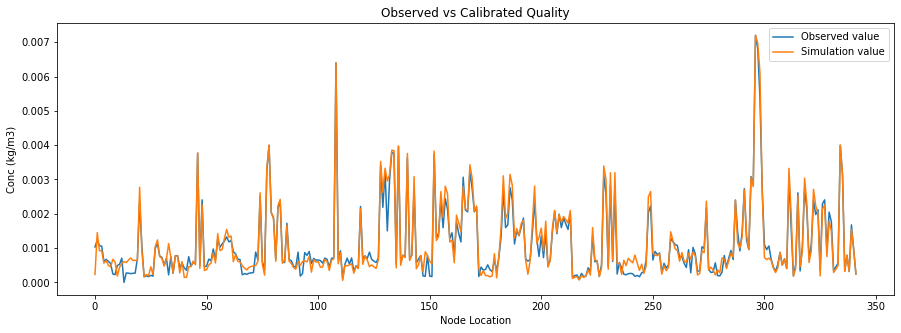

In [52]:
ax=plt.figure(1)
ax.set_figwidth(15)
ax.set_figheight(5)
plt.plot(np.array(dfk11),label="Observed value")
plt.plot(np.array(Cal),label="Simulation value")
#plt.plot(Mdf,color='k')
plt.title("Observed vs Calibrated Quality")
plt.xlabel("Node Location")
plt.ylabel("Conc (kg/m3)")
#plt.ylim(0,0.001)
plt.legend()
plt.savefig('Quality.png', dpi=300,bbox_inches='tight')
plt.show()


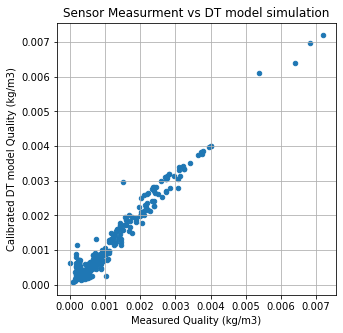

In [94]:
ax=plt.figure(1)
ax.set_figwidth(5)
ax.set_figheight(5)
plt.scatter(dfk11,Cal,marker="o",s=20)
#plt.plot(Mdf,color='k')
plt.grid()
plt.title("Sensor Measurment vs DT model simulation")
plt.xlabel("Measured Quality (kg/m3)")
plt.ylabel("Calibrated DT model Quality (kg/m3)")
#plt.ylim(0,0.001)
#plt.legend()

plt.savefig('Bulk_wall.png', dpi=300,bbox_inches='tight')
plt.show()

In [ ]:
from sklearn.metrics import r2_score
r2_score(dfk11,Cal)

In [45]:
def check(solution):
    #loop 
    for i in range(334):
        wn.add_pattern(f"{i}",[sol[i+429]])
    wn.pattern_name_list

    for i in range(334):
        junction = wn.get_node(pat_n.iloc[i][1])
        junction.demand_timeseries_list[0].pattern_name=A[i]
        #print(junction.demand_timeseries_list[0].pattern_name)
    
   

    dfk = []
    for j in range(len(sol)-334):
        for i in range(len(A2)):
            junction1 = wn.get_link(A2[i])
        junction1.roughness=sol[j]
        #print(junction1.roughness)
        
        # Modify the water network model
    wn.options.time.duration = 3600
    wn.options.time.hydraulic_timestep =7200
    wn.options.time.pattern_timestep = 7200
    wn.options.time.report_timestep =7200
    wn.options.hydraulic.required_pressure = 15
    wn.options.hydraulic.minimum_pressure = 0
        
        # Simulate hydraulics
    sim = wntr.sim.EpanetSimulator(wn)
    #wn.reset_initial_values()
    results = sim.run_sim()
    print(results)
    df=pd.DataFrame(results.node['pressure'])
    dfk = np.array(df)
    dfk1 = dfk[0]
    #dfk1 = np.append(dfk1,(dfk[0][3],dfk[0][5],dfk[0][7],dfk[0][10]))
    #print(dfk1)
        #dfk.append(df1)
            #print(df)
            #df1 = pd.concat([df1,df])
        #print(dfk)
    for i in range(334):
        wn.remove_pattern(f"{i}")
    #P_m1 = np.array([83.421, 83.374,83.508,81.198,36.541])
    sumk1 = np.sum(np.square(Q_m1-dfk1)/P_m1)
    sumk1
    return dfk1

In [46]:
pre_sim = check(result.x)

In [47]:
np.set_printoptions(suppress=True)
pre_sim

array([ 30.032,  65.505,  34.642,  85.43 , 100.154,  29.829,  28.94 ,  25.305,  53.772,  49.68 ,  36.422,  37.236,  58.725,  57.566,  60.908,  51.407,  65.785,  67.11 ,  62.865,  66.254,  65.48 ,  62.636,  66.447,  60.406,  63.58 ,  25.921,  29.852,  27.52 ,  50.809,  58.769,  57.781,  77.929,
        69.342,  50.734,  75.068,  44.988,  52.062,  55.805,  59.344,  61.434,  58.004,  63.64 ,  66.616,  56.656,  57.319,  60.852,  67.942,  32.364,   7.595,  60.453,  62.456,  32.837,  27.213,  22.122,  27.648,  50.067,  36.831,  72.043,  36.226,  50.484,  31.792,  53.007,  46.436,  46.07 ,
        55.012,  51.749,  44.497,  57.412,  60.917,  50.82 ,  63.808,  73.46 ,  50.339,  47.222,  46.173,  21.425,  44.373,  40.757,  45.1  ,  46.61 ,  52.088,  37.463,  39.553,  64.977,  74.184,  54.093,  38.951,  40.   ,  47.374,  62.254,  67.195,  56.616,  57.069,  67.98 ,  49.969,  24.98 ,
        24.98 ,  38.321,  26.784,  34.452,  36.44 ,  74.339,  73.784,  43.959,  57.878,  74.179,  78.905,  74.479, 

In [48]:
np.set_printoptions(suppress=True)
P_m1

array([ 30.616,  65.588,  35.048,  84.152, 100.874,  30.072,  29.229,  25.58 ,  54.731,  50.634,  37.212,  38.028,  58.843,  57.714,  61.013,  52.4  ,  66.779,  67.133,  62.882,  66.277,  65.521,  62.682,  66.468,  61.612,  63.525,  26.227,  30.12 ,  27.809,  50.968,  58.931,  57.955,  78.639,
        70.048,  50.893,  75.789,  45.174,  54.487,  58.2  ,  60.316,  62.426,  58.995,  64.633,  66.68 ,  57.602,  58.162,  61.791,  69.271,  33.587,   8.244,  60.605,  62.698,  33.525,  27.897,  22.828,  28.586,  51.378,  37.735,  73.493,  37.163,  51.63 ,  32.688,  54.145,  47.068,  46.712,
        55.596,  52.274,  44.75 ,  57.478,  61.418,  53.176,  63.881,  75.17 ,  52.817,  48.051,  46.993,  22.384,  44.876,  41.273,  45.565,  46.988,  52.069,  38.926,  41.016,  65.788,  74.818,  55.469,  40.327,  40.   ,  48.653,  63.113,  68.065,  57.901,  57.688,  68.61 ,  51.11 ,  25.653,
        25.652,  39.432,  27.679,  35.467,  37.459,  76.05 ,  74.505,  44.132,  58.008,  75.89 ,  80.617,  76.19 , 

In [49]:
#89.7674951	83.42123319	82.28255253	83.37433371	82.62774656	83.50848089	84.78401914	81.19787163	77.7556742	0	36.54123727


In [50]:
np.shape(pre_sim)

(396,)

In [51]:
A = np.array([91.267, 84.556, 82.319, 83.397, 82.771, 83.459, 84.829, 81.272, 77.624,  0.   , 36.576])

In [52]:
#([89.767, 83.421, 82.283, 83.374, 82.628, 83.508, 84.784, 81.198, 77.756,  0.   , 36.541])

In [53]:
P_m1-pre_sim

array([ 0.584,  0.083,  0.406, -1.278,  0.72 ,  0.243,  0.288,  0.275,  0.959,  0.955,  0.79 ,  0.792,  0.118,  0.148,  0.105,  0.993,  0.993,  0.023,  0.017,  0.023,  0.04 ,  0.046,  0.021,  1.205, -0.055,  0.307,  0.267,  0.288,  0.159,  0.162,  0.174,  0.71 ,  0.705,  0.159,  0.721,  0.186,
        2.425,  2.395,  0.972,  0.991,  0.992,  0.993,  0.063,  0.946,  0.843,  0.938,  1.329,  1.223,  0.649,  0.152,  0.242,  0.688,  0.683,  0.706,  0.938,  1.311,  0.904,  1.45 ,  0.937,  1.146,  0.896,  1.138,  0.632,  0.642,  0.584,  0.525,  0.253,  0.066,  0.501,  2.356,  0.073,  1.71 ,
        2.478,  0.829,  0.821,  0.959,  0.503,  0.515,  0.465,  0.378, -0.018,  1.463,  1.463,  0.81 ,  0.634,  1.376,  1.376, -0.   ,  1.279,  0.859,  0.87 ,  1.285,  0.619,  0.63 ,  1.14 ,  0.672,  0.672,  1.111,  0.895,  1.016,  1.02 ,  1.711,  0.721,  0.173,  0.13 ,  1.711,  1.712,  1.711,
        1.536,  1.685,  1.173,  1.173,  1.182,  1.262,  1.164,  1.37 ,  1.293,  1.34 ,  1.167,  0.15 ,  0.152,  1.0

In [54]:
np.sum(P_m1-pre_sim)

280.7392848371956

In [55]:
#0	1.216582355	1.171850395	1.179924098	1.269814018	1.161229137	1.239236085	1.191264475	1.236951437	1.290636688


In [56]:
'''89
105
109
111
95
87
98
102
94
110
94
89'''


'89\n105\n109\n111\n95\n87\n98\n102\n94\n110\n94\n89'